Training on: cpu
Epoch     0 | Total: 4.25e-01 | PDE: 2.90e-03 | BC: 1.31e-02 | IC: 4.09e-01
Epoch   500 | Total: 7.85e-04 | PDE: 5.91e-04 | BC: 1.03e-04 | IC: 9.10e-05
Epoch  1000 | Total: 3.17e-04 | PDE: 1.41e-04 | BC: 1.17e-04 | IC: 5.95e-05
Epoch  1500 | Total: 1.13e-04 | PDE: 4.54e-05 | BC: 4.21e-05 | IC: 2.52e-05
Epoch  2000 | Total: 8.85e-05 | PDE: 2.08e-05 | BC: 4.37e-05 | IC: 2.40e-05
Epoch  2500 | Total: 2.44e-05 | PDE: 1.53e-05 | BC: 5.10e-06 | IC: 3.98e-06
Epoch  3000 | Total: 1.64e-05 | PDE: 1.08e-05 | BC: 3.19e-06 | IC: 2.43e-06
Epoch  3500 | Total: 1.54e-05 | PDE: 9.61e-06 | BC: 3.85e-06 | IC: 1.96e-06
Epoch  4000 | Total: 7.11e-05 | PDE: 8.89e-06 | BC: 4.23e-05 | IC: 1.99e-05
Epoch  4500 | Total: 1.03e-05 | PDE: 7.77e-06 | BC: 1.54e-06 | IC: 1.02e-06
Epoch  5000 | Total: 9.82e-06 | PDE: 7.29e-06 | BC: 1.49e-06 | IC: 1.04e-06


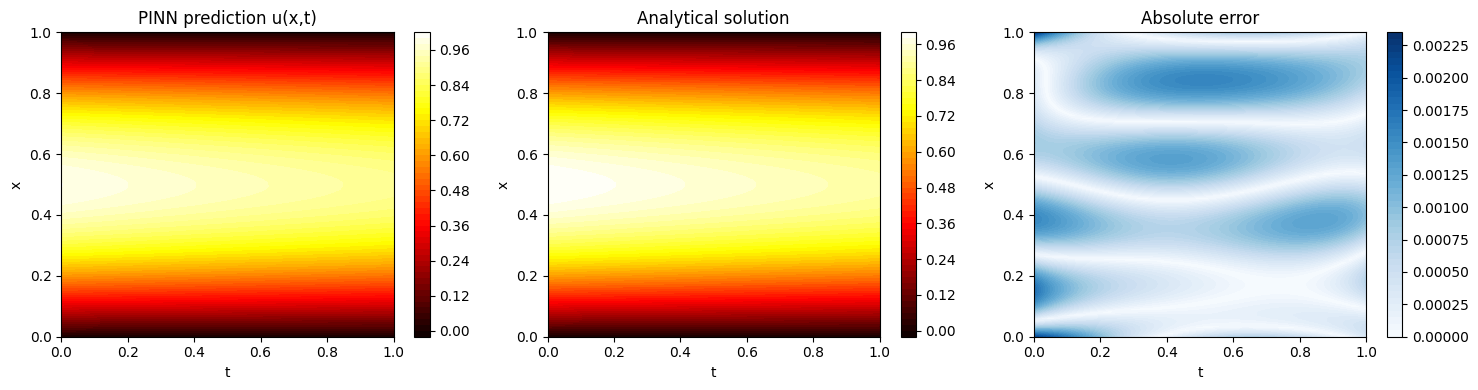


Max error: 0.0023 | Mean error: 0.0006


In [5]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ── Model ──────────────────────────────────────────────────────────────────────
class PINN_Heat(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 1)
        )
    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

# ── Loss functions ──────────────────────────────────────────────────────────────
def pde_loss(model, x, t, alpha=0.01):
    x = x.clone().requires_grad_(True)
    t = t.clone().requires_grad_(True)
    u = model(x, t)
    u_t  = torch.autograd.grad(u, t, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_x  = torch.autograd.grad(u, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), retain_graph=True, create_graph=True)[0]
    return torch.mean((u_t - alpha * u_xx) ** 2)

def bc_loss(model, t_bc):
    """Boundary conditions: u(0,t) = 0  and  u(1,t) = 0"""
    x0 = torch.zeros_like(t_bc)
    x1 = torch.ones_like(t_bc)
    u_left  = model(x0, t_bc)
    u_right = model(x1, t_bc)
    return torch.mean(u_left**2) + torch.mean(u_right**2)

def ic_loss(model, x_ic):
    """Initial condition: u(x,0) = sin(pi * x)"""
    t0 = torch.zeros_like(x_ic)
    u_pred = model(x_ic, t0)
    u_true = torch.sin(np.pi * x_ic)
    return torch.mean((u_pred - u_true) ** 2)

# ── Sampling helper ─────────────────────────────────────────────────────────────
def sample(n):
    """Random points in [0,1] x [0,1]"""
    return torch.rand(n, 1), torch.rand(n, 1)

# ── Training ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

model = PINN_Heat().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

losses = []
N = 1000  # collocation points

for epoch in range(5001):
    optimizer.zero_grad()

    x_f, t_f = [v.to(device) for v in sample(N)]      # PDE interior
    _, t_bc   = [v.to(device) for v in sample(200)]    # boundary (x irrelevant)
    x_ic, _   = [v.to(device) for v in sample(200)]    # IC (t=0)

    L_pde = pde_loss(model, x_f, t_f)
    L_bc  = bc_loss(model, t_bc)
    L_ic  = ic_loss(model, x_ic)

    loss = L_pde + L_bc + L_ic
    loss.backward()
    optimizer.step()
    scheduler.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d} | Total: {loss.item():.2e} | "
              f"PDE: {L_pde.item():.2e} | BC: {L_bc.item():.2e} | IC: {L_ic.item():.2e}")
        losses.append(loss.item())

# ── Visualization ───────────────────────────────────────────────────────────────
model.eval()
x_vis = torch.linspace(0, 1, 100).view(-1, 1)
t_vis = torch.linspace(0, 1, 100).view(-1, 1)
X, T  = torch.meshgrid(x_vis.squeeze(), t_vis.squeeze(), indexing='ij')

with torch.no_grad():
    xf = X.reshape(-1,1).to(device)
    tf = T.reshape(-1,1).to(device)
    U  = model(xf, tf).reshape(100, 100).cpu().numpy()

# Analytical solution: u(x,t) = sin(pi*x) * exp(-alpha * pi^2 * t)
alpha = 0.01
U_exact = (np.sin(np.pi * X.numpy()) *
           np.exp(-alpha * np.pi**2 * T.numpy()))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].contourf(T.numpy(), X.numpy(), U, levels=50, cmap='hot')
axes[0].set_title('PINN prediction u(x,t)')
axes[0].set_xlabel('t'); axes[0].set_ylabel('x')
plt.colorbar(axes[0].contourf(T.numpy(), X.numpy(), U, levels=50, cmap='hot'), ax=axes[0])

axes[1].contourf(T.numpy(), X.numpy(), U_exact, levels=50, cmap='hot')
axes[1].set_title('Analytical solution')
axes[1].set_xlabel('t'); axes[1].set_ylabel('x')
plt.colorbar(axes[1].contourf(T.numpy(), X.numpy(), U_exact, levels=50, cmap='hot'), ax=axes[1])

error = np.abs(U - U_exact)
axes[2].contourf(T.numpy(), X.numpy(), error, levels=50, cmap='Blues')
axes[2].set_title('Absolute error')
axes[2].set_xlabel('t'); axes[2].set_ylabel('x')
plt.colorbar(axes[2].contourf(T.numpy(), X.numpy(), error, levels=50, cmap='Blues'), ax=axes[2])

plt.tight_layout()
plt.savefig('pinn_result.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nMax error: {error.max():.4f} | Mean error: {error.mean():.4f}")

In [7]:
# ── Step 1: Clone your repo ────────────────────────────────────────────────────
!git clone https://github.com/sonu037/NPTEL_SciML_Portfolio.git /content/NPTEL_SciML_Portfolio

# ── Step 2: Verify it worked ───────────────────────────────────────────────────
!ls /content/NPTEL_SciML_Portfolio

fatal: destination path '/content/NPTEL_SciML_Portfolio' already exists and is not an empty directory.
01_CFD_Simulations    03_Materials_AI	05_Intro_ML
02_SciML_Engineering  04_Deep_Learning	fluid_classifier_graph.png


In [8]:
import os
os.chdir('/content/NPTEL_SciML_Portfolio')
!git pull origin main
print("Ready:", os.getcwd())

From https://github.com/sonu037/NPTEL_SciML_Portfolio
 * branch            main       -> FETCH_HEAD
Already up to date.
Ready: /content/NPTEL_SciML_Portfolio


In [9]:
import os

# ── Go into your existing repo folder ──────────────────────────────────────────
os.chdir('/content/NPTEL_SciML_Portfolio')

# ── Pull latest changes first (important — avoids conflicts) ───────────────────
!git pull origin main

From https://github.com/sonu037/NPTEL_SciML_Portfolio
 * branch            main       -> FETCH_HEAD
Already up to date.


In [10]:
# ── Create the folder ──────────────────────────────────────────────────────────
!mkdir -p 02_SciML_Engineering/PINN_Heat_Equation

# ── Save your notebook as a Python script ──────────────────────────────────────
!jupyter nbconvert --to script /content/your_notebook_name.ipynb \
    --output /content/NPTEL_SciML_Portfolio/02_SciML_Engineering/PINN_Heat_Equation/pinn_heat_equation

# ── Copy your result plot ──────────────────────────────────────────────────────
!cp /content/pinn_result.png 02_SciML_Engineering/PINN_Heat_Equation/

[NbConvertApp] WARNING | pattern '/content/your_notebook_name.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=Tru

In [11]:
# Find your actual notebook name
!ls /content/*.ipynb

ls: cannot access '/content/*.ipynb': No such file or directory


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
# Search for all notebooks in your Drive
!find /content/drive/MyDrive -name "*.ipynb" 2>/dev/null


/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb


In [14]:
# Check which one has your PINN code
!grep -l "PINN_Heat\|pde_loss\|physics_loss" \
    "/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb" \
    "/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb"


/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
